In [2]:
import numpy as np
import matplotlib.pyplot as plt
from LAPD_decomp import *

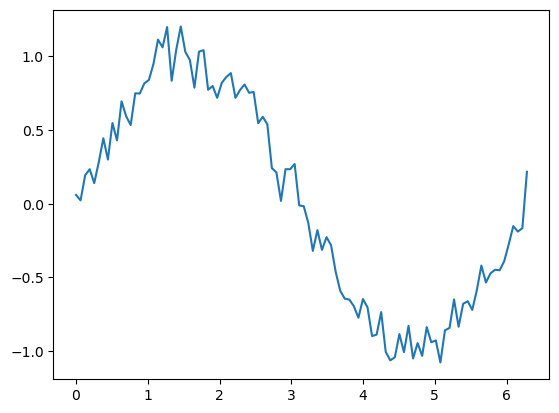

In [11]:
x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)
y_noisy = y + np.random.normal(loc=0, scale=0.1, size=y.shape)
plt.plot(x, y_noisy)

In [12]:
window_size = 10

# Create a convolution kernel (weights for the average)
weights = np.ones(window_size) / window_size

# Apply convolution with 'valid' mode to get results only where the window fully overlaps
moving_avg_np = np.convolve(y_noisy, weights, mode='same')

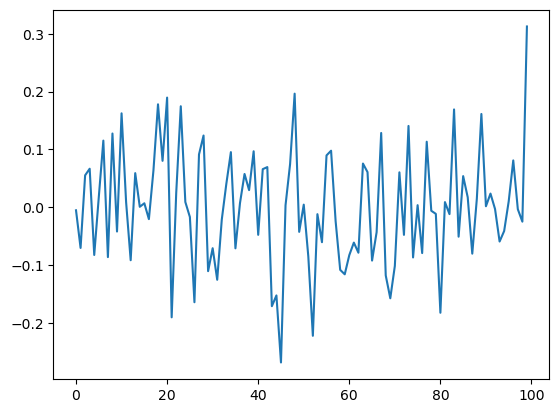

In [13]:
plt.plot(y_noisy-moving_avg_np)

In [3]:
import h5py

filename = '/home/stsoukalas/shared/data/LAPD_Alfven_2025-02/b37-40.hdf5'

# GETTING DATASETS
f = h5py.File(filename, 'r')
Bvec = f['B vectors/Bvec']
times = f['B amplitudes/Timesteps']
spatial_coords = f['Spatial grid']

it=0
iz=1

Bx, By, Bz = get_comps(Bvec, it, iz)
Bx_rec_cart, By_rec_cart, Bz_rec_cart, X, Y = experimental_pipeline(Bx, By, Bz, spatial_coords)

In [4]:
Bx_t = np.transpose(Bvec[:,iz]['DATA_X'], axes=(1,2,0))
By_t = np.transpose(Bvec[:,iz]['DATA_Y'], axes=(1,2,0))
Bz_t = np.transpose(Bvec[:,iz]['DATA_Z'], axes=(1,2,0))
x, y, z = get_LAPD_domain(spatial_coords)

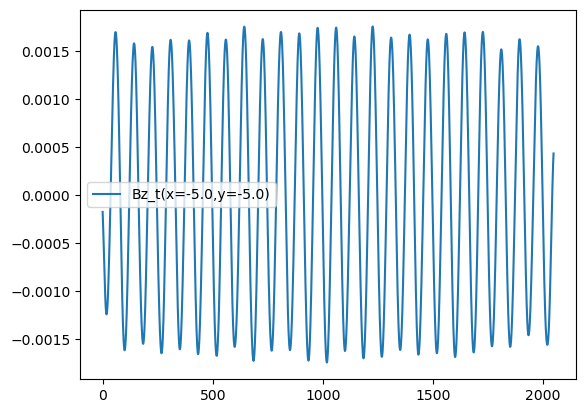

In [5]:
ix = 10
iy = 10
plt.plot(Bz_t[ix, iy], label=f'Bz_t(x={x[ix]},y={y[iy]})')
plt.legend()
# plt.plot(Bz_t[ix, iy])

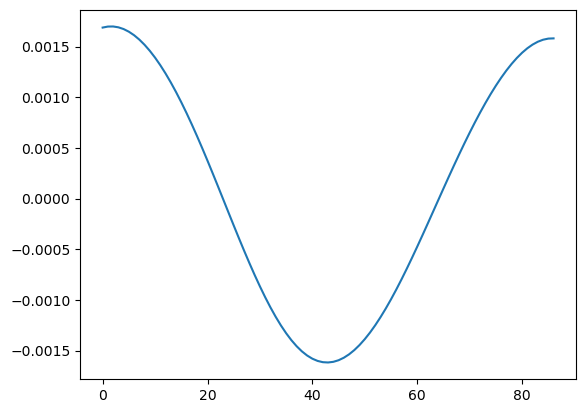

In [6]:
wave = Bz_t[ix,iy][57:144]
plt.plot(wave)
period = times[144]-times[57]

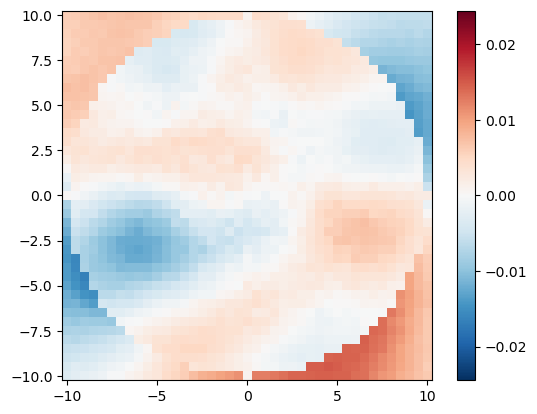

In [31]:
bound = np.max(np.abs(Bx_rec_cart))
plt.pcolormesh(X, Y, Bx-Bx_rec_cart, cmap='RdBu_r', vmin=-bound, vmax=bound)
plt.gca().set_aspect('equal')
plt.colorbar()

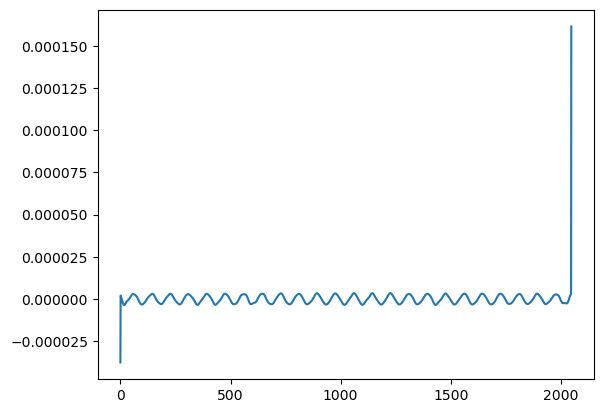

In [7]:
window_size = 3

# Create a convolution kernel (weights for the average)
weights = np.ones(window_size) / window_size

# Apply convolution with 'valid' mode to get results only where the window fully overlaps
moving_avg_np = np.convolve(Bz_t[ix,iy], weights, mode='same')

plt.plot(Bz_t[ix,iy]-moving_avg_np)

Text(0.5, 0, 'Timestep')

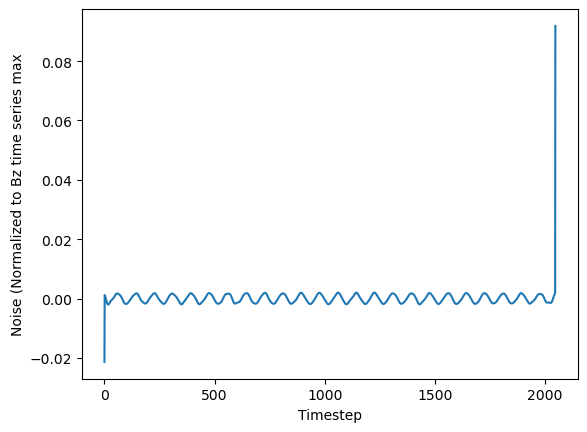

In [10]:
step=10
window_size = 3
weights = np.ones(window_size) / window_size

# for ix in range(0, len(x), step):
#     for iy in range(0, len(y), step):
B_t = Bz_t[ix, iy]
norm = np.max(np.abs(B_t))
moving_avg = np.convolve(B_t, weights, mode='same')
plt.plot((B_t-moving_avg)/norm, label=f'x={x[ix]}, y={y[iy]}')
plt.ylabel('Noise (Normalized to Bz time series max')
plt.xlabel('Timestep')
# plt.legend()
